# Part 2 — Image-Level Predictors of Consistency

Tests what distinguishes a highly-consistent image from a poorly-consistent
one. Two candidate predictors are tested: response sparsity/magnitude (neural,
from Part 1 outputs) and CNN-based image features (ResNet50 layer embeddings,
from the preprocessed archive). The headline test is a nested-R² model
comparison — does adding the CNN's (LOO cross-validated) prediction improve
fit over sparsity alone? Partial-correlation estimates are also reported, but
only as a robustness check: they are more method-sensitive (see Fig. S2) and
are not the primary evidence.

**Depends on:** `part1_outputs.npz`, `cnn_embeddings.npz`

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler

SEED = 42
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors            = apply_plot_style()
COL_DATA          = colors["COL_DATA"]           # default scatter point color
COL_FIT           = colors["COL_FIT"]            # fit lines
COL_REF           = colors["COL_REF"]            # reference lines / baselines
COL_CNN_PRIMARY   = colors["COL_CNN_PRIMARY"]    # ResNet50 primary layer highlight
COL_CNN_SECONDARY = colors["COL_CNN_SECONDARY"]  # ResNet50 secondary layer highlight

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES = manifest['n_images']

p1 = np.load(OUTPUTS_DIR / 'part1_outputs.npz')
consistency    = p1['consistency']       # (118,)
mean_sparsity  = p1['mean_sparsity']    # (118,)
mean_magnitude = p1['mean_magnitude']   # (118,)

cnn_data    = np.load(ARCHIVE_DIR / 'cnn_embeddings.npz')
layer_names = ['layer1', 'layer2', 'layer3', 'layer4', 'final']
layer_emb   = {name: cnn_data[name] for name in layer_names}

print(f'Images: {N_IMAGES}')
print(f'Consistency range: [{consistency.min():.3f}, {consistency.max():.3f}]')
print(f'CNN layers: {[(k, v.shape) for k, v in layer_emb.items()]}')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
Images: 118
Consistency range: [0.142, 0.588]
CNN layers: [('layer1', (118, 256)), ('layer2', (118, 512)), ('layer3', (118, 1024)), ('layer4', (118, 2048)), ('final', (118, 1000))]


## 2.1 — Sparsity and magnitude as image-level predictors

Sparsity is defined as the fraction of units responding below the per-mouse
median absolute z-score — a threshold-free measure robust to session-level
differences in overall firing rate. Both predictors were averaged across mice
(already done in Part 1) before correlating with consistency.

In [3]:
r_sp,  p_sp  = spearmanr(consistency, mean_sparsity)
r_mag, p_mag = spearmanr(consistency, mean_magnitude)
print(f'Consistency vs. sparsity  : r = {r_sp:+.3f},  p = {p_sp:.2e}')
print(f'Consistency vs. magnitude : r = {r_mag:+.3f},  p = {p_mag:.2e}')

Consistency vs. sparsity  : r = -0.470,  p = 7.84e-08
Consistency vs. magnitude : r = +0.276,  p = 2.51e-03


## 2.2 — CNN feature embeddings

ResNet50 pretrained on ImageNet (IMAGENET1K_V2) is used as a feature
extractor. Global average pooling reduces each convolutional block to a
fixed-length vector per image. Ridge LOO regression (n=118 images) is used
because feature dimension >> n_images makes OLS ill-posed.

Two separate CNN quantities are tested against sparsity, and they should not
be conflated:
- `cnn_proxy`, a scalar (per-image mean activation of layer 2) — a weak
  raw predictor (r ~ -0.02) — used only as a quick diagnostic below.
- `layer_results['layer2']['y_pred']`, the full 512-dim ridge LOO
  prediction (r = -0.496) — this is the actual predictive CNN signal, and
  it is this quantity, not the scalar proxy, that is compared against
  sparsity below (nested R², plus partial correlation as a secondary check).

In [4]:
CNN_PRIMARY   = 'layer2'   # best single-layer predictor
CNN_SECONDARY = 'final'    # comparably-performing layer (Fig 2C); tested here too so
                            # the independence-from-sparsity result isn't an artifact
                            # of having picked layer2 specifically.

layer_results = {}
for name, emb in layer_emb.items():
    Xs     = StandardScaler().fit_transform(emb)
    loo    = LeaveOneOut()
    y_pred = cross_val_predict(
        RidgeCV(alphas=np.logspace(-2, 6, 30)), Xs, consistency, cv=loo)
    r, p   = pearsonr(consistency, y_pred)
    layer_results[name] = {'r': r, 'r2': r**2, 'p': p, 'y_pred': y_pred}
    print(f'{name:>8s}: LOO r = {r:+.3f},  R² = {r**2:.3f},  p = {p:.2e}')


def partial_spearman(x, y, cov):
    """Non-parametric partial correlation via rank-residualisation."""
    def resid(a, b):
        ar = pd.Series(a).rank().values.astype(float)
        br = pd.Series(b).rank().values.astype(float)
        return ar - LinearRegression().fit(
            br.reshape(-1, 1), ar).predict(br.reshape(-1, 1))
    return spearmanr(resid(x, cov), resid(y, cov))


# ── Diagnostic only: scalar mean-activation proxy (weak raw predictor) ────────
cnn_proxy   = layer_emb[CNN_PRIMARY].mean(axis=1)   # scalar per image
r_raw, p_raw = spearmanr(cnn_proxy, consistency)
r_par, p_par = partial_spearman(cnn_proxy, consistency, mean_sparsity)

print(f'\n[diagnostic] {CNN_PRIMARY} mean activation (scalar proxy) vs consistency:')
print(f'  Raw Spearman r            : {r_raw:+.3f},  p = {p_raw:.2e}')
print(f'  Partial r (sparsity ctrl) : {r_par:+.3f},  p = {p_par:.2e}')

# ── Nested R² (headline) + partial correlation (secondary check): does the ────
# ── full CNN model (LOO prediction) add signal beyond sparsity? Both layers. ──
partial_results = {}
for layer in (CNN_PRIMARY, CNN_SECONDARY):
    cnn_pred_l = layer_results[layer]['y_pred']
    r_par_l, p_par_l = partial_spearman(cnn_pred_l, consistency, mean_sparsity)

    r2_sparsity_only_l = LinearRegression().fit(
        mean_sparsity.reshape(-1, 1), consistency).score(
        mean_sparsity.reshape(-1, 1), consistency)
    X_nested = np.column_stack([mean_sparsity, cnn_pred_l])
    r2_sparsity_plus_cnn_l = LinearRegression().fit(
        X_nested, consistency).score(X_nested, consistency)

    partial_results[layer] = {
        'cnn_pred': cnn_pred_l,
        'r_par_full': r_par_l, 'p_par_full': p_par_l,
        'r2_sparsity_only': r2_sparsity_only_l,
        'r2_sparsity_plus_cnn': r2_sparsity_plus_cnn_l,
    }

    print(f'\n{layer} full LOO-prediction vs consistency:')
    print(f'  Raw LOO Pearson r                  : {layer_results[layer]["r"]:+.3f}')
    print(f'  R² sparsity alone                  : {r2_sparsity_only_l:.3f}')
    print(f'  R² sparsity + CNN LOO prediction   : {r2_sparsity_plus_cnn_l:.3f}')
    print(f'  Delta R² from adding CNN prediction : {r2_sparsity_plus_cnn_l - r2_sparsity_only_l:+.3f}')
    print(f'  [secondary] Partial r (sparsity ctrl) : {r_par_l:+.3f},  p = {p_par_l:.2e}')

# Backward-compatible aliases (primary = layer2), used below and in the figures.
cnn_pred             = partial_results[CNN_PRIMARY]['cnn_pred']
r_par_full           = partial_results[CNN_PRIMARY]['r_par_full']
p_par_full           = partial_results[CNN_PRIMARY]['p_par_full']
r2_sparsity_only     = partial_results[CNN_PRIMARY]['r2_sparsity_only']
r2_sparsity_plus_cnn = partial_results[CNN_PRIMARY]['r2_sparsity_plus_cnn']

  layer1: LOO r = -0.298,  R² = 0.089,  p = 1.03e-03


  layer2: LOO r = -0.496,  R² = 0.246,  p = 1.11e-08


  layer3: LOO r = -0.182,  R² = 0.033,  p = 4.90e-02


  layer4: LOO r = -0.243,  R² = 0.059,  p = 8.09e-03


   final: LOO r = -0.486,  R² = 0.236,  p = 2.48e-08

[diagnostic] layer2 mean activation (scalar proxy) vs consistency:
  Raw Spearman r            : -0.017,  p = 8.55e-01
  Partial r (sparsity ctrl) : +0.094,  p = 3.13e-01

layer2 full LOO-prediction vs consistency:
  Raw LOO Pearson r                  : -0.496
  R² sparsity alone                  : 0.269
  R² sparsity + CNN LOO prediction   : 0.453
  Delta R² from adding CNN prediction : +0.184
  [secondary] Partial r (sparsity ctrl) : -0.828,  p = 5.47e-31

final full LOO-prediction vs consistency:
  Raw LOO Pearson r                  : -0.486
  R² sparsity alone                  : 0.269
  R² sparsity + CNN LOO prediction   : 0.374
  Delta R² from adding CNN prediction : +0.105
  [secondary] Partial r (sparsity ctrl) : -0.887,  p = 9.85e-41


## Added-variable analysis (supplementary robustness check)

Added-variable plots show the partial effect of each predictor after
controlling for the other. These are residualised against
`layer_results['layer2']['y_pred']` (the full 512-dim ridge LOO prediction),
not the scalar `cnn_proxy`, since it is the full model that carries the
predictive signal being compared against sparsity. These partial-r estimates
are reported as a robustness check alongside the nested-R² result (Fig. 2D),
not as the primary evidence — see Fig. S2 for why.

In [5]:
def ols_resid(y, x):
    """Residuals of y ~ x (OLS, with intercept)."""
    X_ = np.column_stack([np.ones(len(x)), x])
    b  = np.linalg.lstsq(X_, y, rcond=None)[0]
    return y - X_ @ b

resid_cons_vs_sp = ols_resid(consistency, mean_sparsity)   # same for every layer

av_results = {}
for layer in (CNN_PRIMARY, CNN_SECONDARY):
    cnn_pred_l = partial_results[layer]['cnn_pred']

    resid_cons_vs_cnn_l = ols_resid(consistency,  cnn_pred_l)
    resid_sp_vs_cnn_l   = ols_resid(mean_sparsity, cnn_pred_l)
    resid_cnn_vs_sp_l   = ols_resid(cnn_pred_l,    mean_sparsity)

    r_av_sp_l,  _ = pearsonr(resid_sp_vs_cnn_l,  resid_cons_vs_cnn_l)
    r_av_cnn_l, _ = pearsonr(resid_cnn_vs_sp_l,  resid_cons_vs_sp)

    av_results[layer] = {
        'resid_cons_vs_cnn': resid_cons_vs_cnn_l,
        'resid_sp_vs_cnn':   resid_sp_vs_cnn_l,
        'resid_cnn_vs_sp':   resid_cnn_vs_sp_l,
        'r_av_sp': r_av_sp_l, 'r_av_cnn': r_av_cnn_l,
    }
    print(f'{layer}: Added-variable partial r — sparsity | CNN : {r_av_sp_l:+.3f};  '
          f'CNN | sparsity : {r_av_cnn_l:+.3f}')

# Backward-compatible aliases (primary = layer2), used by the figures below.
resid_cons_vs_cnn = av_results[CNN_PRIMARY]['resid_cons_vs_cnn']
resid_sp_vs_cnn   = av_results[CNN_PRIMARY]['resid_sp_vs_cnn']
resid_cnn_vs_sp   = av_results[CNN_PRIMARY]['resid_cnn_vs_sp']
r_av_sp  = av_results[CNN_PRIMARY]['r_av_sp']
r_av_cnn = av_results[CNN_PRIMARY]['r_av_cnn']

layer2: Added-variable partial r — sparsity | CNN : -0.523;  CNN | sparsity : -0.501
final: Added-variable partial r — sparsity | CNN : -0.424;  CNN | sparsity : -0.378


---
## Figures

**Fig. 2** (2×2) — Response sparsity and CNN-layer features each capture
distinct variance in cross-mouse consistency. A: sparsity. B: magnitude. C:
LOO accuracy by ResNet50 layer. D: nested R² — the CNN's LOO prediction
improves fit over sparsity alone (ΔR² = +0.184 layer2, +0.105 final), the
robust, model-comparison version of the independence claim.

**S2** — Partial-correlation robustness detail, kept out of the main figure
because these estimates are method-sensitive: (A) the residual scatter
clouds underlying the added-variable partial r, (B) the same for the reverse
direction, (C) a non-parametric partialling method (rank-residualized
Spearman) that yields a substantially larger partial r than either the
added-variable or nested-R² estimates — a signature of statistical
suppression, and the reason these partial-r values are reported here as
illustrative rather than as headline evidence — and (D) a nested-R² summary
table comparing both partialling methods side by side.


Fig 2A — consistency vs. response sparsity

--- mean_sparsity ---
shape=(118,)
[0.520492 0.546472 0.482891 0.457203 0.508473 0.426674 0.487684 0.54445  0.519074 0.517934 0.565284 0.59953  0.554183 0.459788 0.480241 0.480375 0.515295 0.42606  0.433015 0.412091]
...[118 elements total]

--- consistency ---
shape=(118,)
[0.422874 0.150347 0.320186 0.409948 0.482925 0.359236 0.40502  0.163267 0.260908 0.19579  0.275605 0.248535 0.290777 0.303716 0.260574 0.379713 0.378248 0.45102  0.32783  0.369047]
...[118 elements total]

--- spearman_r ---
-0.47008790478381707

--- spearman_p ---
7.837762738778079e-08

Fig 2B — consistency vs. response magnitude

--- mean_magnitude ---
shape=(118,)
[0.622436 0.661972 0.758902 0.881167 0.644245 0.967838 0.806265 0.688401 0.752618 0.738666 0.623841 0.584964 0.625305 0.868559 0.752002 0.840273 0.762268 0.911898 0.876095 1.054934]
...[118 elements total]

--- consistency ---
shape=(118,)
[0.422874 0.150347 0.320186 0.409948 0.482925 0.359236 0.40502  0.163

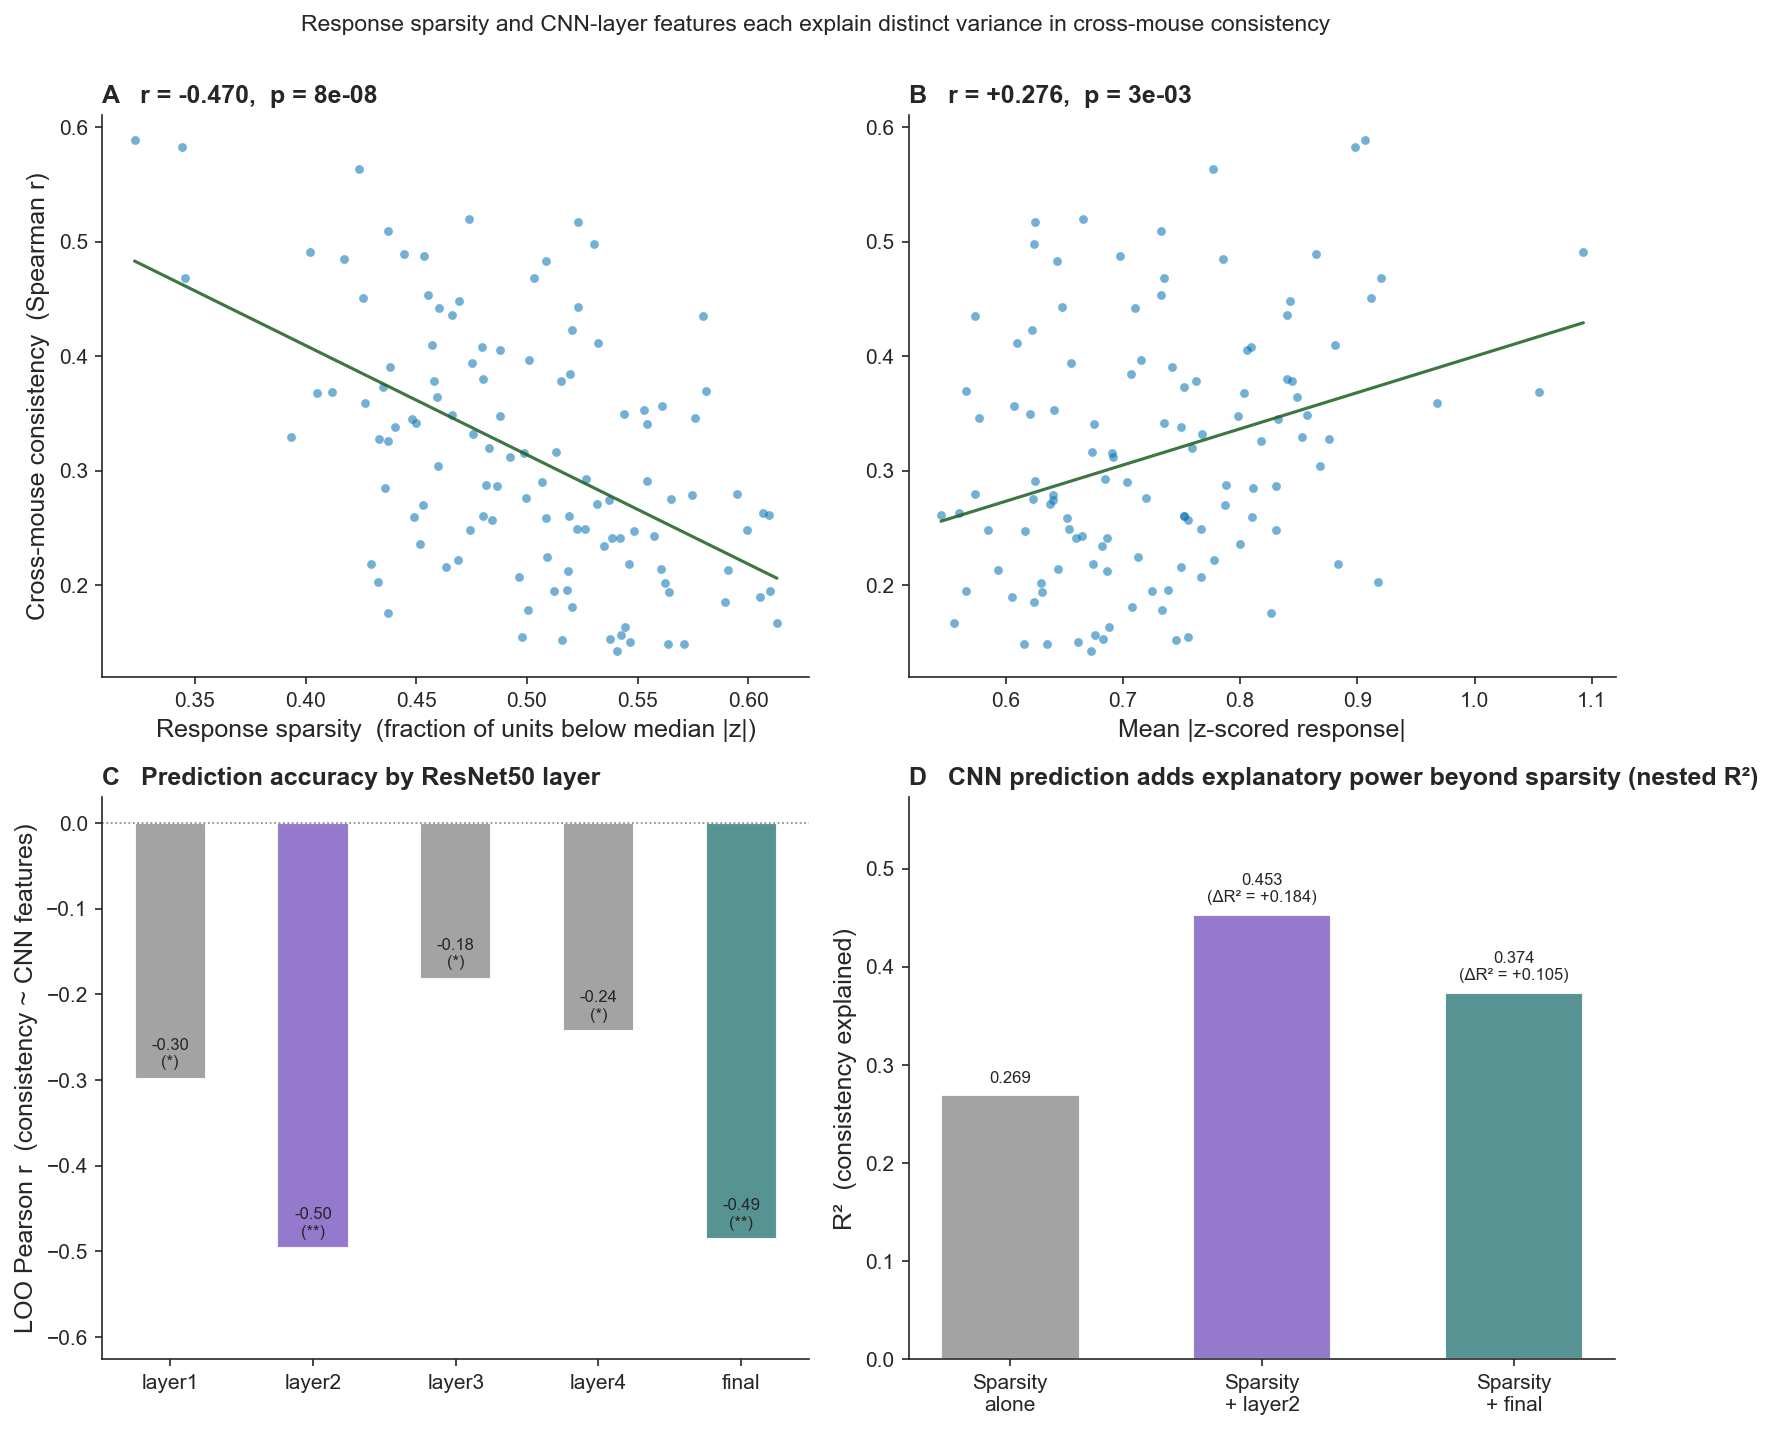

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9.5))
axA, axB = axes[0]
axC, axD = axes[1]

def scatter_with_fit(ax, x, y, r, p, xlabel, title_letter, color=COL_DATA):
    ax.scatter(x, y, s=18, alpha=0.55, color=color, linewidths=0)
    m, b = np.polyfit(x, y, 1)
    xr   = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m * xr + b, color=COL_FIT, linewidth=1.5, alpha=0.85)
    ax.set_xlabel(xlabel)
    ax.set_title(f'{title_letter}   r = {r:+.3f},  p = {p:.0e}',
                 loc='left', fontweight='bold', pad=6)
    ax.spines[['top', 'right']].set_visible(False)

axA.set_ylabel('Cross-mouse consistency  (Spearman r)')
scatter_with_fit(axA, mean_sparsity, consistency, r_sp, p_sp,
                 'Response sparsity  (fraction of units below median |z|)', 'A')
scatter_with_fit(axB, mean_magnitude, consistency, r_mag, p_mag,
                 'Mean |z-scored response|', 'B')

# Panel C: LOO r per ResNet50 layer
r_vals  = [layer_results[l]['r'] for l in layer_names]
p_vals  = [layer_results[l]['p'] for l in layer_names]
layer_colors = [COL_CNN_PRIMARY if l == CNN_PRIMARY else
                COL_CNN_SECONDARY if l == CNN_SECONDARY else
                COL_REF
                for l in layer_names]
bars = axC.bar(layer_names, r_vals, color=layer_colors, alpha=0.9, width=0.5)
for bar, r, p in zip(bars, r_vals, p_vals):
    sig = '**' if p < 0.001 else ('*' if p < 0.05 else 'n.s.')
    axC.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{r:.2f}\n({sig})', ha='center', va='bottom', fontsize=8)
axC.axhline(0, color='gray', linestyle=':', linewidth=0.8)
axC.set_ylim(min(r_vals) - 0.13, 0.03)
axC.set_ylabel('LOO Pearson r  (consistency ~ CNN features)')
axC.set_title('C   Prediction accuracy by ResNet50 layer',
              loc='left', fontweight='bold', pad=6)
axC.spines[['top', 'right']].set_visible(False)

# Panel D: nested R² — does adding the CNN's LOO prediction improve fit over
# sparsity alone? This is the robust, model-comparison version of the
# independence claim (see Fig. S2 for the partial-correlation estimates,
# which are method-sensitive and reported there as robustness detail, not
# headline evidence).
bar_labels = ['Sparsity\nalone', f'Sparsity\n+ {CNN_PRIMARY}', f'Sparsity\n+ {CNN_SECONDARY}']
bar_vals   = [r2_sparsity_only,
              partial_results[CNN_PRIMARY]['r2_sparsity_plus_cnn'],
              partial_results[CNN_SECONDARY]['r2_sparsity_plus_cnn']]
bar_colors = [COL_REF, COL_CNN_PRIMARY, COL_CNN_SECONDARY]

x    = np.arange(len(bar_labels))
bars = axD.bar(x, bar_vals, color=bar_colors, alpha=0.9, width=0.55)
for i, (bar, v) in enumerate(zip(bars, bar_vals)):
    label = f'{v:.3f}'
    if i > 0:
        d_r2 = v - r2_sparsity_only
        label += f'\n(ΔR² = {d_r2:+.3f})'
    axD.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             label, ha='center', va='bottom', fontsize=8)
axD.set_xticks(x)
axD.set_xticklabels(bar_labels)
axD.set_ylim(0, max(bar_vals) + 0.12)
axD.set_ylabel('R²  (consistency explained)')
axD.set_title('D   CNN prediction adds explanatory power beyond sparsity (nested R²)',
              loc='left', fontweight='bold', pad=6)
axD.spines[['top', 'right']].set_visible(False)

fig.suptitle('Response sparsity and CNN-layer features each explain distinct variance in cross-mouse consistency',
             fontsize=11, y=1.0)

print_figure_data(
    'Fig 2A — consistency vs. response sparsity',
    mean_sparsity=mean_sparsity,
    consistency=consistency,
    spearman_r=r_sp,
    spearman_p=p_sp,
)
print_figure_data(
    'Fig 2B — consistency vs. response magnitude',
    mean_magnitude=mean_magnitude,
    consistency=consistency,
    spearman_r=r_mag,
    spearman_p=p_mag,
)
print_figure_data(
    'Fig 2C — LOO Pearson r per ResNet50 layer',
    layer_names=layer_names,
    loo_r_per_layer=np.array(r_vals),
    p_per_layer=np.array(p_vals),
)
print_figure_data(
    'Fig 2D — nested R²: sparsity alone vs. sparsity + CNN LOO prediction (layer2 & final)',
    bar_labels=bar_labels,
    bar_vals=np.array(bar_vals),
    delta_r2_layer2=partial_results[CNN_PRIMARY]['r2_sparsity_plus_cnn'] - r2_sparsity_only,
    delta_r2_final=partial_results[CNN_SECONDARY]['r2_sparsity_plus_cnn'] - r2_sparsity_only,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_image_predictors.png', bbox_inches='tight')
plt.show()


Fig S2A — added-variable residual clouds, sparsity | CNN (layer2 and final)

--- layer2_sparsity_residual_given_cnn ---
shape=(118,)
[ 0.024906  0.045171 -0.013089 -0.028733  0.014612 -0.07204  -0.007331  0.041812  0.019649  0.017499  0.057528  0.099719  0.05332  -0.040015 -0.019195 -0.018141  0.017381 -0.071321 -0.058263
 -0.086466]
...[118 elements total]

--- final_sparsity_residual_given_cnn ---
shape=(118,)
[ 0.029765  0.042621 -0.015002 -0.034595  0.019986 -0.071409 -0.007567  0.038262  0.019004  0.014695  0.065833  0.098843  0.056122 -0.038702 -0.020225 -0.016129  0.020454 -0.063259 -0.063323
 -0.083262]
...[118 elements total]

--- layer2_consistency_residual_given_cnn ---
shape=(118,)
[ 0.081258 -0.153536 -0.01883   0.004606  0.129919  0.038273  0.059627 -0.131785 -0.055364 -0.113809  0.01435  -0.065181 -0.015994 -0.010054 -0.055622  0.057443  0.052005  0.121248 -0.042242
  0.047047]
...[118 elements total]

--- final_consistency_residual_given_cnn ---
shape=(118,)
[ 0.085902

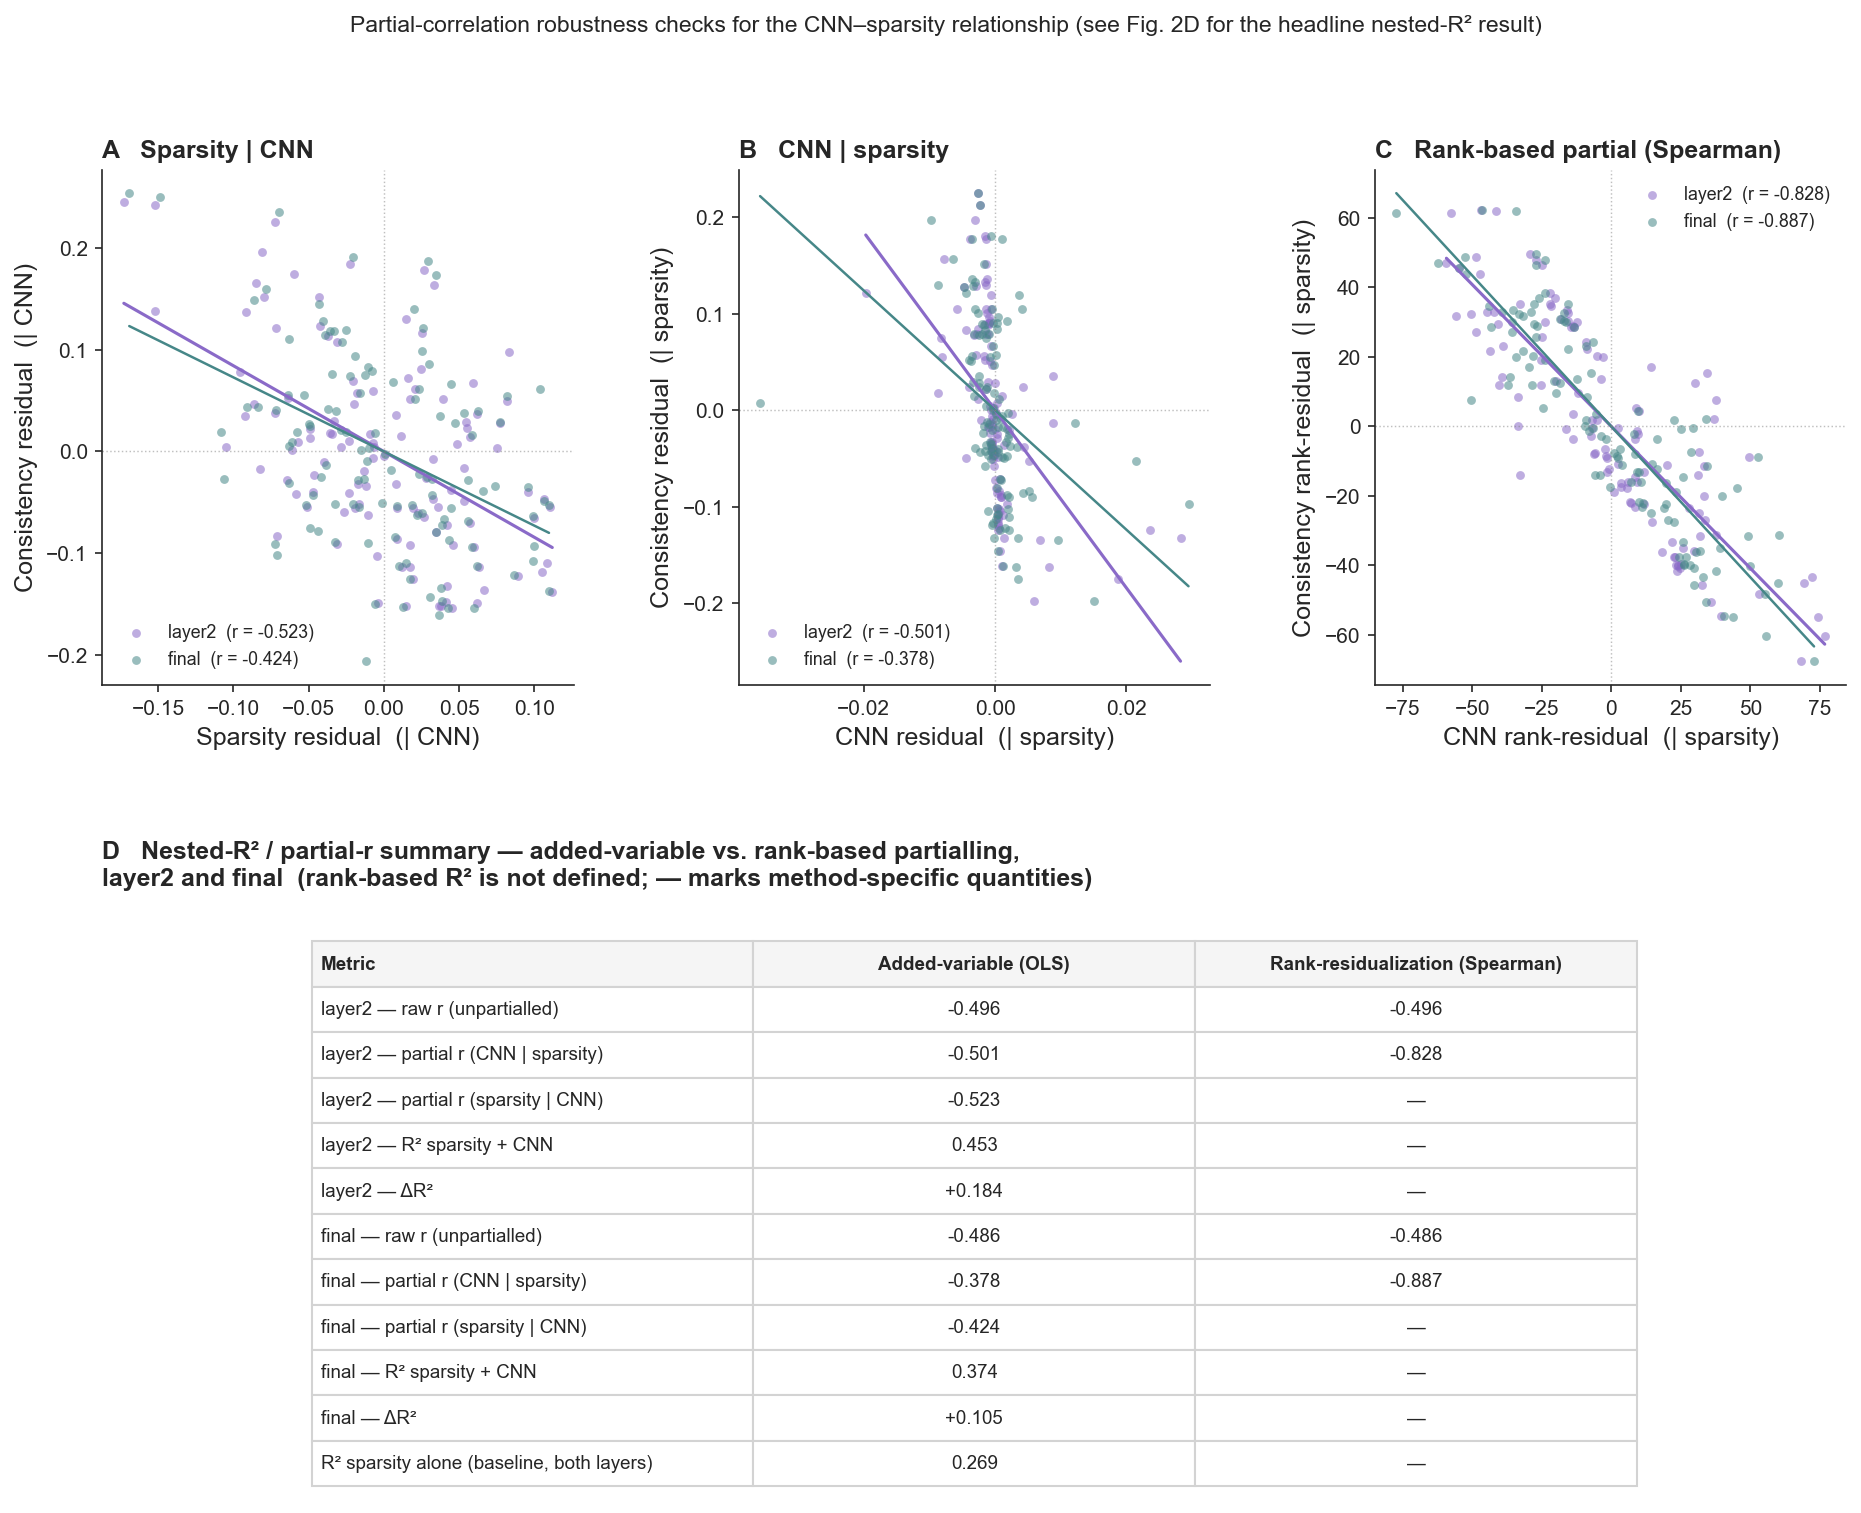

In [7]:
def rank_resid(a, b):
    """Rank-residualise a on b (used for the Spearman partial correlation)."""
    ar = pd.Series(a).rank().values.astype(float)
    br = pd.Series(b).rank().values.astype(float)
    return ar - LinearRegression().fit(br.reshape(-1, 1), ar).predict(br.reshape(-1, 1))

rank_resid_results = {}
for layer in (CNN_PRIMARY, CNN_SECONDARY):
    rank_resid_results[layer] = {
        'cnn':  rank_resid(partial_results[layer]['cnn_pred'], mean_sparsity),
        'cons': rank_resid(consistency, mean_sparsity),
    }

# Fixed per-layer identity color, held constant across panels A/B/C — same
# CNN-layer palette used in Fig 2C/D.
LAYER_STYLE = {
    CNN_PRIMARY:   {'marker': 'o', 'alpha': 0.55, 'color': COL_CNN_PRIMARY},
    CNN_SECONDARY: {'marker': 'o', 'alpha': 0.55, 'color': COL_CNN_SECONDARY},
}

fig = plt.figure(figsize=(15, 11.5))
gs  = fig.add_gridspec(2, 3, height_ratios=[1, 1.15], hspace=0.4, wspace=0.35)
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])
axD = fig.add_subplot(gs[1, :])
axD.axis('off')

def resid_scatter_multi(ax, xy_by_layer, xlabel, ylabel, title):
    """xy_by_layer: {layer: (x, y, r)}"""
    for layer, (x, y, r) in xy_by_layer.items():
        style = LAYER_STYLE[layer]
        ax.scatter(x, y, s=18, alpha=style['alpha'], color=style['color'], linewidths=0,
                   marker=style['marker'], label=f'{layer}  (r = {r:+.3f})')
        m, b = np.polyfit(x, y, 1)
        xr   = np.linspace(x.min(), x.max(), 100)
        ax.plot(xr, m * xr + b, color=style['color'],
                linewidth=1.5 if layer == CNN_PRIMARY else 1.2,
                linestyle='-' if layer == CNN_PRIMARY else '-')
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left', fontweight='bold', pad=6)
    ax.legend(frameon=False, fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)

# Panel A — sparsity | CNN residual clouds, layer2 and final
resid_scatter_multi(
    axA,
    {layer: (av_results[layer]['resid_sp_vs_cnn'], av_results[layer]['resid_cons_vs_cnn'],
             av_results[layer]['r_av_sp']) for layer in (CNN_PRIMARY, CNN_SECONDARY)},
    'Sparsity residual  (| CNN)', 'Consistency residual  (| CNN)',
    'A   Sparsity | CNN')

# Panel B — CNN | sparsity residual clouds, layer2 and final
resid_scatter_multi(
    axB,
    {layer: (av_results[layer]['resid_cnn_vs_sp'], resid_cons_vs_sp,
             av_results[layer]['r_av_cnn']) for layer in (CNN_PRIMARY, CNN_SECONDARY)},
    'CNN residual  (| sparsity)', 'Consistency residual  (| sparsity)',
    'B   CNN | sparsity')

# Panel C — rank-based (Spearman) partial correlation, layer2 and final. Larger
# magnitude than the added-variable r's in A/B and than the raw LOO r's —
# a signature of statistical suppression (sparsity shares variance with both
# consistency and the CNN prediction, so removing it from both can inflate
# residual alignment). Directionally consistent with panels A/B, but the
# magnitude swing across methods (-0.50 to -0.83) means this number should be
# read as illustrative, not as a precise effect size — see Fig. 2D's nested
# R² for the robust estimate of how much the CNN model adds.
resid_scatter_multi(
    axC,
    {layer: (rank_resid_results[layer]['cnn'], rank_resid_results[layer]['cons'],
             partial_results[layer]['r_par_full']) for layer in (CNN_PRIMARY, CNN_SECONDARY)},
    'CNN rank-residual  (| sparsity)', 'Consistency rank-residual  (| sparsity)',
    'C   Rank-based partial (Spearman)')

# Panel D — belt-and-suspenders nested-R² / partial-r summary, both methods and
# both layers side by side
table_rows = []
for layer in (CNN_PRIMARY, CNN_SECONDARY):
    pr = partial_results[layer]
    av = av_results[layer]
    table_rows += [
        [f'{layer} — raw r (unpartialled)',        f'{layer_results[layer]["r"]:+.3f}', f'{layer_results[layer]["r"]:+.3f}'],
        [f'{layer} — partial r (CNN | sparsity)',  f'{av["r_av_cnn"]:+.3f}',             f'{pr["r_par_full"]:+.3f}'],
        [f'{layer} — partial r (sparsity | CNN)',  f'{av["r_av_sp"]:+.3f}',              '—'],
        [f'{layer} — R² sparsity + CNN',           f'{pr["r2_sparsity_plus_cnn"]:.3f}',  '—'],
        [f'{layer} — ΔR²',                         f'{pr["r2_sparsity_plus_cnn"] - pr["r2_sparsity_only"]:+.3f}', '—'],
    ]
table_rows.append(['R² sparsity alone (baseline, both layers)', f'{r2_sparsity_only:.3f}', '—'])
col_labels = ['Metric', 'Added-variable (OLS)', 'Rank-residualization (Spearman)']
tbl = axD.table(cellText=table_rows, colLabels=col_labels,
                 cellLoc='center', colLoc='center', loc='upper center',
                 bbox=[0.12, 0.02, 0.76, 0.92])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('lightgray')
    if row == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('whitesmoke')
    if col == 0:
        cell.set_text_props(ha='left')
        cell.PAD = 0.02
axD.set_title('D   Nested-R² / partial-r summary — added-variable vs. rank-based partialling,\n'
              f'{CNN_PRIMARY} and {CNN_SECONDARY}  (rank-based R² is not defined; '
              '— marks method-specific quantities)',
              loc='left', fontweight='bold', pad=10)

fig.suptitle('Partial-correlation robustness checks for the CNN–sparsity relationship (see Fig. 2D for the headline nested-R² result)',
             fontsize=11, y=0.97)

print_figure_data(
    'Fig S2A — added-variable residual clouds, sparsity | CNN (layer2 and final)',
    **{f'{layer}_sparsity_residual_given_cnn': av_results[layer]['resid_sp_vs_cnn'] for layer in (CNN_PRIMARY, CNN_SECONDARY)},
    **{f'{layer}_consistency_residual_given_cnn': av_results[layer]['resid_cons_vs_cnn'] for layer in (CNN_PRIMARY, CNN_SECONDARY)},
    **{f'{layer}_partial_r_sparsity_given_cnn': av_results[layer]['r_av_sp'] for layer in (CNN_PRIMARY, CNN_SECONDARY)},
)
print_figure_data(
    'Fig S2B — added-variable residual clouds, CNN | sparsity (layer2 and final)',
    consistency_residual_given_sparsity=resid_cons_vs_sp,
    **{f'{layer}_cnn_residual_given_sparsity': av_results[layer]['resid_cnn_vs_sp'] for layer in (CNN_PRIMARY, CNN_SECONDARY)},
    **{f'{layer}_partial_r_cnn_given_sparsity': av_results[layer]['r_av_cnn'] for layer in (CNN_PRIMARY, CNN_SECONDARY)},
)
print_figure_data(
    'Fig S2C — rank-based (Spearman) partial correlation, CNN | sparsity (layer2 and final)',
    **{f'{layer}_cnn_rank_residual': rank_resid_results[layer]['cnn'] for layer in (CNN_PRIMARY, CNN_SECONDARY)},
    consistency_rank_residual=rank_resid_results[CNN_PRIMARY]['cons'],
    **{f'{layer}_partial_spearman_r': partial_results[layer]['r_par_full'] for layer in (CNN_PRIMARY, CNN_SECONDARY)},
    **{f'{layer}_partial_spearman_p': partial_results[layer]['p_par_full'] for layer in (CNN_PRIMARY, CNN_SECONDARY)},
)
print_figure_data(
    'Fig S2D — nested R² / partial-r summary table (layer2 and final)',
    table_rows=np.array(table_rows),
    col_labels=np.array(col_labels),
)

plt.savefig(FIGURES_DIR / 'figS2_cnn_detail.png', bbox_inches='tight')
plt.show()